In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
from moc.configs.config import get_config
from moc.utils.run_config import RunConfig
# from moc.models.mqf2.lightning_module import MQF2LightningModule
from moc.models.mixture.mixture_model2 import MixtureLightningModule
from moc.models.gaussian.gaussian import GaussianLightningModule
from moc.models.trainers.lightning_trainer import get_lightning_trainer
from moc.datamodules.real_datamodule import RealDataModule
import numpy as np
import matplotlib.pyplot as plt
from moc.metrics.distribution_metrics import pce, multivariate_energy_score, mse
import torch
import glob

In [3]:
torch.set_printoptions(precision=3, sci_mode=False, threshold=float('inf'), edgeitems=40, linewidth=200)
np.set_printoptions(suppress=True, formatter={'float_kind':'{:.3f}'.format})

In [4]:
config = get_config()
config.device = 'cuda'
data_group, data_name = 'mulan', 'sf2'
rc = RunConfig(config, data_group, data_name)
datamodule = RealDataModule(rc, num_workers=8)
p, q = datamodule.input_dim, datamodule.output_dim

tensor(8.)


In [45]:
ckpt_path = "/mnt/default/elnura_workspace/Multivariate-recalibration/Multicalibration/Projected_PIT_calibration/logs/2025-07-09/15-18-14-sf2tuning/mulan/sf2/model=mixture,prerank=cdf,lambda=10.0/0/checkpoints/epoch_0300.ckpt"
model = MixtureLightningModule.load_from_checkpoint(ckpt_path)
model.eval().to(config.device)
test_loader = datamodule.test_dataloader()

In [48]:
pces, cdfs = [], []
prerank = 'marginal'
for x, y in test_loader:
    x = x.to(config.device)
    y = y.to(config.device)
    dist = model.predict(x)
    print(f"model was trained on {model.hparams.prerank} but evaluating on {prerank}")
    pce_val, _ = pce(dist, y, n_samples=model.hparams.es_num_samples, prerank=prerank)
    #pce_val is of hsape 3 and cdfs are of shape 3, 100
    pces.append(pce_val)
    cdfs.append(_)
pce_total = torch.stack(pces).mean(dim=0)
cdfs_total = torch.stack(cdfs).mean(dim=0)
print(pce_total.shape, cdfs_total.shape)
    # nlls.append(nll_value.item())
    # energies.append(energy_val.item())

model was trained on cdf but evaluating on marginal
torch.Size([3]) torch.Size([3, 100])


In [13]:
colors = [
    "#1f77b4",  # muted blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # yellow-green
    "#17becf",  # cyan
    "#aec7e8",  # light blue
    "#ffbb78",  # light orange
    "#98df8a",  # light green
    "#ff9896",  # light red
    "#c5b0d5",  # light purple
    "#c49c94",  # light brown
]

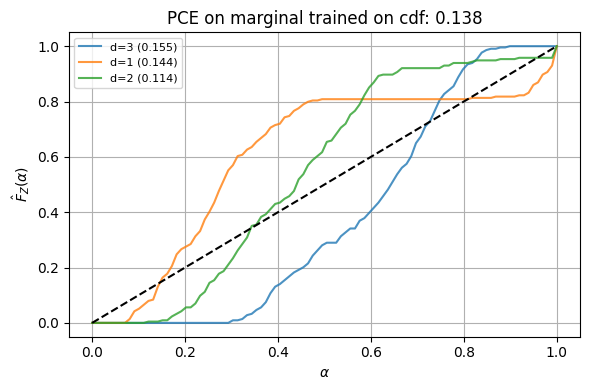

In [49]:
alphas = np.linspace(0, 1, 100)
sorted_indices = torch.argsort(pce_total, descending=True)  # or ascending=False

plt.figure(figsize=(6, 4))
for rank, d in enumerate(sorted_indices):
    d = d.item()
    cdf = cdfs_total[d].cpu().numpy()
    plt.plot(alphas, cdf, color=colors[rank], 
             lw=1.5, alpha=0.8, label=f"d={d+1} ({pce_total[d]:.3f})")

plt.plot(alphas, alphas, linestyle='--', color='black')
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\hat{F}_Z(\alpha)$")
plt.title(f"PCE on {prerank} trained on {model.hparams.prerank}: {pce_total.mean().item():.3f}")
plt.grid(True)
plt.tight_layout()
plt.legend(loc = 'upper left', fontsize=8)
plt.savefig(f"figures/after-reg/{data_name}/rel_plot_{prerank}_{data_name}_mixgauss_trained_on_{model.hparams.prerank}.png", dpi=300)
plt.show()